# SINDy Analysis for Experimental data on Silicon using tappping mode

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import Image
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.linear_model import Lars
from sklearn.linear_model import LassoLars
from pysindy.utils import lorenz, lorenz_control, enzyme
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
import pysindy as ps
import cvxpy
import math

# %run /Users/santiago/Documents/PhD_documents/Python_Simulations/Learning_SINDy/SINDY_example_functions.ipynb

In [ ]:
import scipy.io as sio

def set_plot_style(style_num = 17):
    # Version 2.0: This function sets the style of the images that are generated by matplotlib. 
    # New in Version 2.0: Added functionality to put back the plotting style to 'default' when styly_num = 'default'.
    plt.style.use('default')
    plt.style.use(plt.style.available[style_num])

    if style_num == 'default': # New in version 2.0
        plt.style.use('default')

def load_experimental_data(file_path, file_name, experimental_dt): #, z_static, omega0, normalize=False):

    # data=sio.loadmat('/Users/santiago/Documents/PhD_documents/Python_Simulations/Learning_SINDy/' + file_pathname, struct_as_record=False, squeeze_me=True)
    data=sio.loadmat(file_path + file_name, struct_as_record=False, squeeze_me=True)
    
    disp_fwd = []
    time_fwd = []
    for index in range(data['displacement_fwd_sweep'].shape[0]):
        disp_data = data['displacement_fwd_sweep'][index]
        disp_fwd.append(disp_data)
        num_samples = disp_data.shape[0]
        total_time = (num_samples - 1) * experimental_dt #the "num_samples - 1" ensures the last time point corresponds to the last sample, not one step beyond.
        time_fwd.append(np.linspace(0, total_time, num=num_samples)) # Create time array starting at 0, with the step defined by the sampling interval

    disp_rvs = []
    time_rvs = []
    for index in range(data['displacement_rvs_sweep'].shape[0]):
        disp_data = data['displacement_rvs_sweep'][index]
        disp_rvs.append(disp_data)
        num_samples = disp_data.shape[0]
        total_time = (num_samples - 1) * experimental_dt #the "num_samples - 1" ensures the last time point corresponds to the last sample, not one step beyond.
        time_rvs.append(np.linspace(0, total_time, num=num_samples)) # Create time array starting at 0, with the step defined by the sampling interval

    vel_fwd = []
    for index in range(data['velocity_fwd_sweep'].shape[0]):
        vel_fwd.append(data['velocity_fwd_sweep'][index])

    vel_rvs = [] 
    for index in range(data['velocity_rvs_sweep'].shape[0]):
        vel_rvs.append(data['velocity_rvs_sweep'][index])

    # mult_trajectories = []
    # for index in range(data['displacement_fwd_sweep'].shape[0]):
    #     if normalize:
    #         trajectory_temp = np.vstack(((disp_fwd[index])/z_static, (vel_fwd[index])/(z_static*omega0), (time_fwd[index]*omega0))).T
    #         mult_trajectories.append(trajectory_temp)
    #     else:
    #         trajectory_temp = np.vstack((disp_fwd[index], vel_fwd[index], time_fwd[index])).T
    #         mult_trajectories.append(trajectory_temp)

    return disp_fwd, disp_rvs, vel_fwd, vel_rvs, time_fwd, time_rvs


def load_GP_denoised_signal(denoised_signal_file):

    loaded = np.load(denoised_signal_file + ".npz")
    time_pred_loaded = loaded["time_pred"]
    data_pred_disp_loaded = loaded["data_pred"]
    sigma_desp_loaded = loaded["sigma"]

    data_pred_vel_loaded = np.gradient(data_pred_disp_loaded, time_pred_loaded.flatten())

    x_train = np.vstack((data_pred_disp_loaded, data_pred_vel_loaded, time_pred_loaded.flatten())).T

    return x_train, sigma_desp_loaded


## Experimental data assumptions

Ahbilash used a Silicon cantilever (NCLR, NanoWorld AG) with $k = 22.68$ N/m | $f_0 = 164.52$ kHz | $Q = 428$. This data was taken from Abhilash's thesis, chapter 3.1 page 43.

In [8]:
experimental_dt = 1/250e6  # 250 MHz given by Pierpaolo
Q_factor = 428 # Taken from Ahbilash thesis, chapter 3.1 page 43
omega0 = 164.52e3 # Taken from Ahbilash thesis, chapter 3.1 page 43
z_static=100e-9 # taken from the name of the imported data: "si_HOPG_100nm_0p185V.mat" and from Ahbilash thesis, chapter 3.1 page 43
d1 = 1/(2*Q_factor) 

y_bar = 0.05585 #mock value, must be confirmed. (we maintained a specific excitation amplitude of 0.013V for the dither piezo.)
a0 = 0.0132626 #assumed value, must be confirmed. 

# omega0 = 165e3 # This value is an assumption, it must be properly checked. 

## Load experimental data from Matlab

In [9]:
file_path = '/Users/santiago/Documents/PhD_documents/Python_Simulations/Learning_SINDy/AFM_Abhilash_experimental_data/Silicon/'
file_name = 'rawtimedata_sweep_06_11_18_si_si_100nm_0p016V.mat'

disp_fwd, disp_rvs, vel_fwd, vel_rvs, time_fwd, time_rvs = load_experimental_data(file_path = file_path, file_name = file_name, 
                                                                                  experimental_dt = experimental_dt)
print('The amount of individual trajectories imported is: ' + str(len(disp_fwd)))

The amount of individual trajectories imported is: 501


### Plot of a single trajectory:

Extract and plot the data from a single normalized trajectory

In [10]:
# index = 100 #200#290 #330 this has an amplitude of 1
index = 10 #Silicon index 10 works to show a noisy measurement. 102 was perfect with almost no noise
test_traject = np.vstack(((disp_fwd[index])/z_static, (vel_fwd[index])/(z_static*omega0), (time_fwd[index]*omega0))).T
test_traject_w_units = np.vstack((disp_fwd[index], vel_fwd[index], time_fwd[index])).T
dt = time_fwd[index][2]-time_fwd[index][1] #test_traject[2,2] - test_traject[1,2]
print(time_fwd[index][1]-time_fwd[index][0])

4e-09


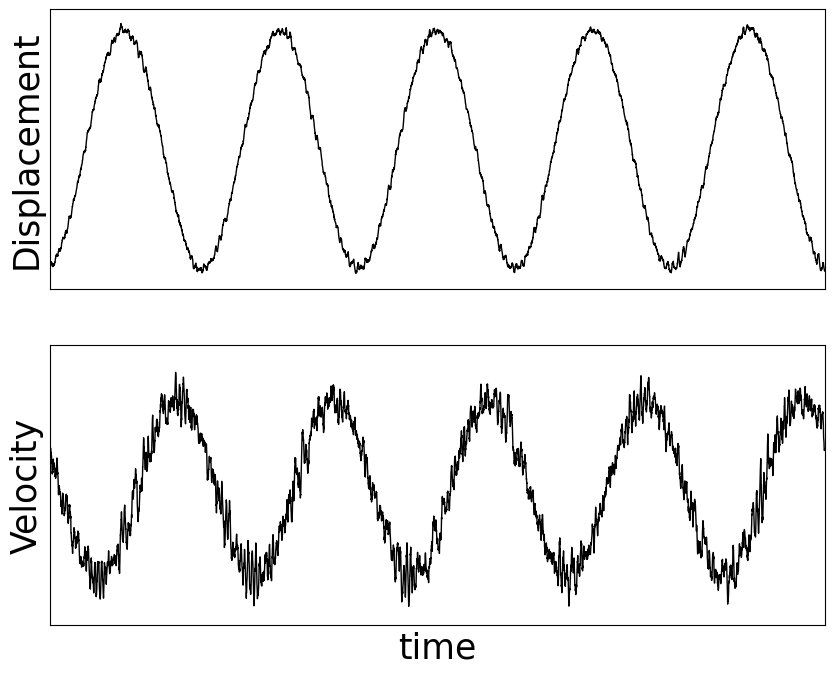

In [11]:
set_plot_style()

# Setup the figure and subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# First subplot for Position
axs[0].plot(test_traject[:,2], test_traject[:,0], linewidth=1.0, label=r'True Position ($\tilde{q}_1$)', color='black')
axs[0].set_xlabel('')  # Remove x-axis label
axs[0].set_xticklabels([])  # Remove x-axis tick labels
axs[0].set_xlim([0, 5.0])  # Updated x-axis limit for milliseconds
axs[0].set_ylabel(r'Displacement', fontsize=25)  # Keep y-axis label
axs[0].tick_params(axis='y', which='major', labelsize=25)  # Customize the font size of the y-axis tick labels

# Second subplot for Velocity
axs[1].plot(test_traject[:,2], test_traject[:,1], linewidth=1.0, label=r'True Velocity ($\tilde{q}_2$)', color='black')
axs[1].set_xlabel(r'time', fontsize=25)  
axs[1].set_ylabel(r'Velocity', fontsize=25)
axs[1].set_xlim([70.0, 75.0])  # Updated x-axis limit for milliseconds
axs[1].tick_params(axis='both', which='major', labelsize=25)  # Customize the font size of the tick labels

axs[0].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
axs[1].tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)

# Saving the figure with a transparent background
# fig.savefig('Silicon_experimental_time_series.png', transparent=True, dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'AFM IM: Velocity Over Time')

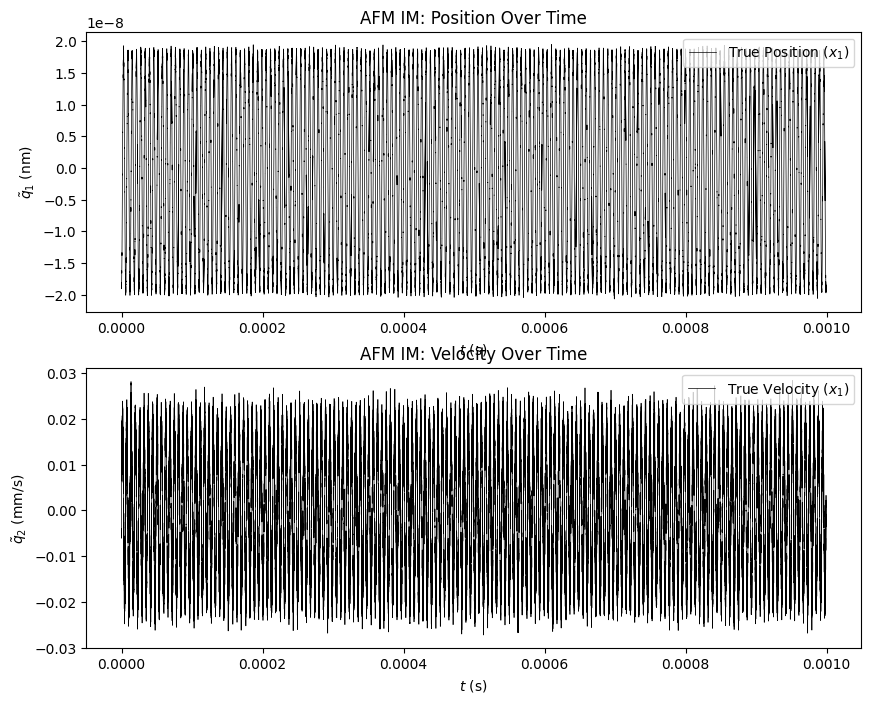

In [12]:
# Setup the figure and subplots
set_plot_style()
fig, axs = plt.subplots(2, 1, figsize=(10, 8))  # 2 Rows, 1 Column

# First subplot for Position
axs[0].plot(test_traject_w_units[:,2], test_traject_w_units[:,0], linewidth=0.5, label='True Position ($x_1$)', color = 'black')
axs[0].set_xlabel(r'$t$ (s)')
axs[0].set_ylabel(r'$\tilde{q}_1$ (nm)')
axs[0].legend(loc = 'upper right')
axs[0].set_title('AFM IM: Position Over Time')
# axs[0].set_xlim([0.00, 0.008])

# # Second subplot for Velocity
axs[1].plot(test_traject_w_units[:,2], test_traject_w_units[:,1], linewidth=0.5, label='True Velocity ($x_1$)', color = 'black')
axs[1].set_xlabel(r'$t$ (s)')
axs[1].set_ylabel(r'$\tilde{q}_2$ (mm/s)')
axs[1].legend(loc = 'upper right')
axs[1].set_title('AFM IM: Velocity Over Time')
# axs[1].set_xlim([0.00, 0.008])

Text(0.5, 1.0, 'AFM IM: Velocity Over Time Dimensionless')

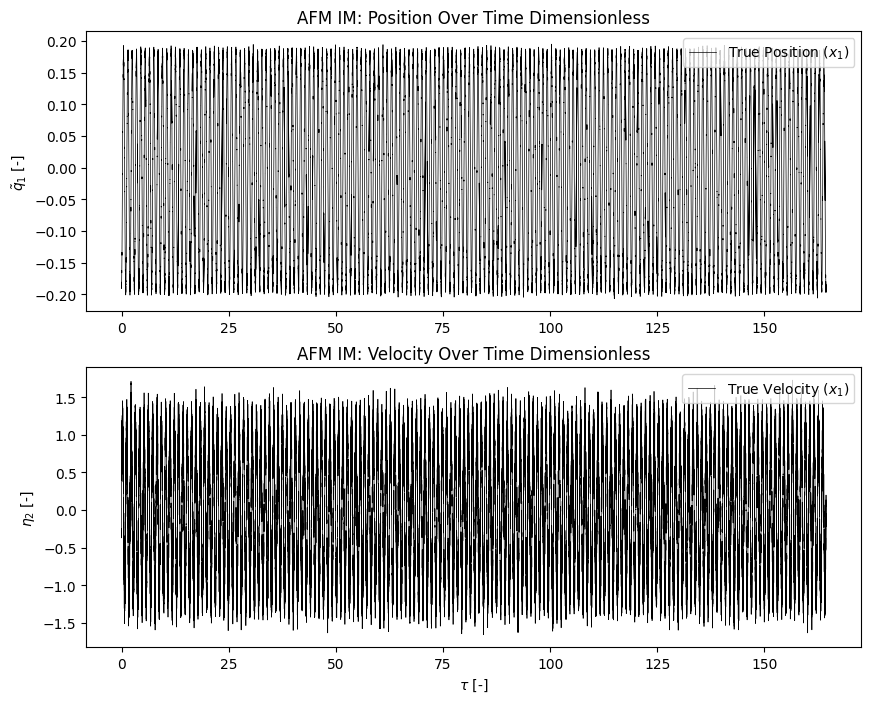

In [26]:
# Setup the figure and subplots
set_plot_style()
fig, axs = plt.subplots(2, 1, figsize=(10, 8))  # 2 Rows, 1 Column

# First subplot for Position
axs[0].plot(test_traject[:,2], test_traject[:,0], linewidth=0.5, label='True Position ($x_1$)', color = 'black')
# axs[0].set_xlabel(r'$t$ (s)')
axs[0].set_ylabel(r'$\tilde{q}_1$ [-]')
axs[0].legend(loc = 'upper right')
axs[0].set_title('AFM IM: Position Over Time Dimensionless')
# axs[0].set_xlim([0.00, 0.008])

# # Second subplot for Velocity
axs[1].plot(test_traject[:,2], test_traject[:,1], linewidth=0.5, label='True Velocity ($x_1$)', color = 'black')
axs[1].set_xlabel(r'$\tau$ [-]')
axs[1].set_ylabel(r'$\eta_2$ [-]')
axs[1].legend(loc = 'upper right')
axs[1].set_title('AFM IM: Velocity Over Time Dimensionless')
# axs[1].set_xlim([0.00, 0.008])

## Load of denoised data

In [14]:
%run /Users/santiago/Documents/PhD_documents/Python_Simulations/Learning_SINDy/SINDY_example_functions.ipynb

loaded_x_train_10, sigma_loaded_10 = load_GP_denoised_signal(denoised_signal_file= 'rawtimedata_sweep_06_11_18_si_si_100nm_0p016V_disp_10')
loaded_x_train_45, sigma_loaded_45 = load_GP_denoised_signal(denoised_signal_file= 'rawtimedata_sweep_06_11_18_si_si_100nm_0p016V_disp_45')
loaded_x_train_50, sigma_loaded_50 = load_GP_denoised_signal(denoised_signal_file= 'rawtimedata_sweep_06_11_18_si_si_100nm_0p016V_disp_50')

### Concatenating imported denoised trajectories

In [15]:
x_train_exp_mult_traj = []

x_train_exp_mult_traj.append(loaded_x_train_10)
x_train_exp_mult_traj.append(loaded_x_train_45)
x_train_exp_mult_traj.append(loaded_x_train_50)

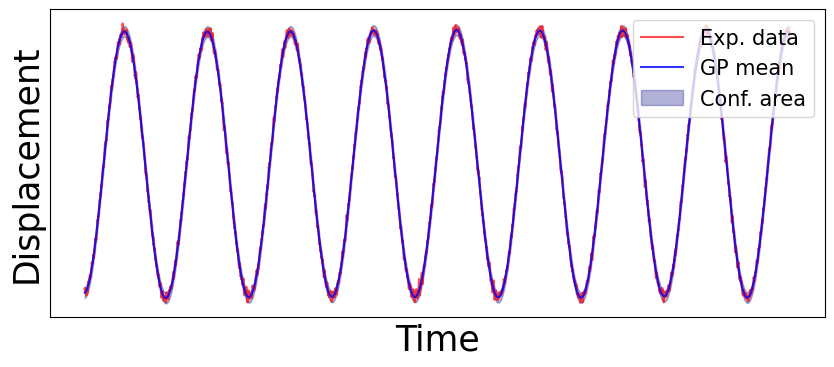

In [16]:
set_plot_style()
# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

traject_to_plot = x_train_exp_mult_traj[0]
sigma_to_plot = sigma_loaded_10

ax.plot(test_traject[:traject_to_plot.shape[0],2], test_traject[:traject_to_plot.shape[0],0], color='red', markersize=1, alpha = 0.7, label='Exp. data', zorder = 2)
ax.plot(traject_to_plot[:,2], traject_to_plot[:,0], color='blue', alpha = 0.8, label='GP mean', zorder = 3)
ax.fill_between(traject_to_plot[:,2].ravel(), traject_to_plot[:,0] - 2*sigma_to_plot, traject_to_plot[:,0] + 2*sigma_to_plot, color='navy', alpha=0.3, label='Conf. area', zorder = 1)

# axs.legend(loc='upper left')
ax.set_ylabel(r'Displacement', fontsize=25)
ax.set_xlabel(r'Time', fontsize=25)
ax.legend(loc = 'upper right', fontsize=15)

# Customizing tick labels size
ax.tick_params(axis='both', which='major', labelsize=25)  # Customize the font size of the tick labels
ax.tick_params(axis='both', which='major', labelsize=25)  # Customize the font size of the tick label

ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
# plt.savefig('Dynamic_AFM_exp_data_GP.png', transparent=True, dpi=300, bbox_inches='tight')

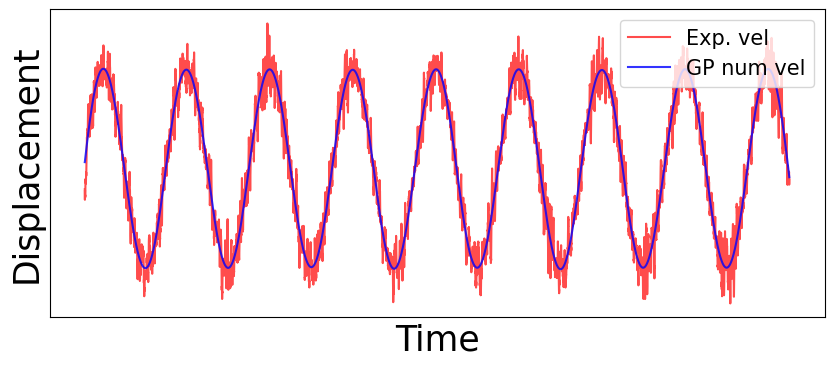

In [17]:
set_plot_style()
# Create plot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(test_traject[:traject_to_plot.shape[0],2], test_traject[:traject_to_plot.shape[0],1], color='red', markersize=1, alpha = 0.7, label='Exp. vel', zorder = 2)
ax.plot(traject_to_plot[:,2], traject_to_plot[:,1], color='blue', alpha = 0.8, label='GP num vel', zorder = 3)

# axs.legend(loc='upper left')
ax.set_ylabel(r'Displacement', fontsize=25)
ax.set_xlabel(r'Time', fontsize=25)
ax.legend(loc = 'upper right', fontsize=15)

# Customizing tick labels size
ax.tick_params(axis='both', which='major', labelsize=25)  # Customize the font size of the tick labels
ax.tick_params(axis='both', which='major', labelsize=25)  # Customize the font size of the tick label

ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
# plt.savefig('Dynamic_AFM_exp_data_GP.png', transparent=True, dpi=300, bbox_inches='tight')

## Preliminary analysis with normal SINDy

In [18]:
%run /Users/santiago/Documents/PhD_documents/Python_Simulations/Learning_SINDy/SINDY_example_functions.ipynb

index = 0

library_functions, library_function_names = create_candidate_func_w_func_names(DOF = 3, poly= True, poly_degrees=[1], 
                                                                                sin = True, cos = False, n_frequencies=[1], 
                                                                                AFM_amp=y_bar, special = False, special_degrees= None,
                                                                                AFM_LJ_z=False, poly_frac=False,
                                                                                exp_damp = False, z_b_val = 0.15, exp_damp_degrees = [1, 2],
                                                                                AFM_z = False, AFM_z_degrees = [2],
                                                                                AFM_z_damp=False, AFM_z_damp_degrees_e1 = [1, 2], AFM_z_damp_degrees_e2 = [1, 2],
                                                                                a0_val = a0, DMT_rep = True, DMT_rep_smooth = False, DMT_rep_degrees = [1.5, 2, 2.5],
                                                                                DMT_att = True, DMT_neg_att = False, DMT_att_degrees = [2,3], # 3,4,5,6,7,8
                                                                                DMT_rep_adh = True, DMT_rep_adh_degrees = [2],
                                                                                DMT_viscoel_damp=False, DMT_visc_elast_degrees_e1 = [0.5], DMT_visc_elast_degrees_e2 = [2],
                                                                                sin_denominator=False, cos_denominator=False)

lib_concat = ps.CustomLibrary(library_functions=library_functions, function_names=library_function_names, interaction_only=True, include_bias=True)
lib_concat.fit(x_train_exp_mult_traj[index])

In [19]:
feature_names = ['e1', 'e2', 'phase']
# sparse_regression_optimizer = ps.SR3(threshold=1e-5, nu = 0.1, max_iter=10000)    #lamda = (threshold)^2/(2*nu)
# model_LJ_normal = ps.SINDy(feature_names=feature_names, optimizer=sparse_regression_optimizer, feature_library=lib_concat)
model_DMT_normal = ps.SINDy(feature_names=feature_names, feature_library=lib_concat)
model_DMT_normal.fit(x_train_exp_mult_traj, t=dt, ensemble=True, multiple_trajectories = True, quiet = True) 
model_DMT_normal.print(precision=9)

(e1)' = 3.202516670 1 + -39.313234058 e1 + 164519.949466432 e2 + 0.057872654 phase + 44.697041605 sin(1*e1) + 0.070751714 sin(1*e2) + 0.595545115 sin(1*phase) + -6.786050792 (1-e1)^-2 + 2.810668544 (1-e1)^-3 + 5.640092314 (0.0132626-1+e2)^1.5 + 0.608204587 (0.0132626-1+phase)^1.5 + -10.064850065 (0.0132626-1+e2)^2 + -0.243003180 (0.0132626-1+phase)^2 + 4.583709926 (0.0132626-1+e2)^2.5
(e2)' = -36947.421420422 1 + -6939897.783587781 e1 + 764.359933557 e2 + -16547.807511063 phase + 496739.537519876 sin(1*e1) + 588.419258637 sin(1*e2) + 5030.235797899 sin(1*phase) + 7910.669860807 (1-e1)^-2 + -0.231341415 (1-e2)^-2 + 13.578941826 (1-phase)^-2 + 1726.889457844 (1-e1)^-3 + -0.182365708 (1-phase)^-3 + -53427.709714225 (0.0132626-1+e2)^1.5 + 28418.092727399 (0.0132626-1+phase)^1.5 + 87448.493008434 (0.0132626-1+e2)^2 + -11982.736187551 (0.0132626-1+phase)^2 + -38205.301095873 (0.0132626-1+e2)^2.5 + 1351.003426815 (0.0132626-1+phase)^2.5
(phase)' = 164519.999999982 1 + -0.000000326 e1 + 0.0000

### Creation of candidate funciton library Dataframe with Pandas

In [20]:
SINDy_cand_func_df= pd.DataFrame(columns=["Candidate Function"])

for idx, cand_func in enumerate(model_DMT_normal.get_feature_names()):
    SINDy_cand_func_df.loc[idx] = [cand_func]

SINDy_cand_func_df

,Candidate Function
0,1
1,e1
2,e2
3,phase
4,sin(1*e1)
5,sin(1*e2)
6,sin(1*phase)
7,(1-e1)^-2
8,(1-e2)^-2
9,(1-phase)^-2


## SINDy Regime Analysis assuming Repulsive Regime

As the damping coefficient is different in each of the two dynamical regimes, that is $d_1$ for attractive regime and $d_2$ for the repulsive regime, it is assumed at first that all clusters could be attractive clusters to not change the constrains as we train multiple models in multiple clusters.

In [21]:
import pandas as pd
SINDy_constraints_df = pd.DataFrame(columns=["Equation No.", "Candidate Function", "Constraint Value"])

#Special constraints for e1' equation:
SINDy_constraints_df.loc[0] = [0, 'e2', 1]

#Special constraints for e2' equation:
SINDy_constraints_df.loc[1] = [1, 'e1', -1]
SINDy_constraints_df.loc[2] = [1, 'e2', -d1]
SINDy_constraints_df.loc[3] = [1, 'phase', 0]
SINDy_constraints_df.loc[4] = [1, 'sin(1*phase)', y_bar] #HERE IT WAS F_act BEFORE!!!!!!!
SINDy_constraints_df.loc[5] = [1, 'sin(1*e1)', 0]
SINDy_constraints_df.loc[6] = [1, 'sin(1*e2)', 0]
SINDy_constraints_df.loc[7] = [1, '(1-phase)^-3', 0]
SINDy_constraints_df.loc[8] = [1, '(1-phase)^-2', 0]
SINDy_constraints_df.loc[9] = [1, '(1-e2)^-3', 0]
SINDy_constraints_df.loc[10] = [1, '(1-e2)^-2', 0]
SINDy_constraints_df.loc[11] = [1, '(0.0132626-1+e2)^1.5', 0]
SINDy_constraints_df.loc[12] = [1, '(0.0132626-1+phase)^1.5', 0]
SINDy_constraints_df.loc[13] = [1, '(0.0132626-1+e2)^2', 0]
SINDy_constraints_df.loc[14] = [1, '(0.0132626-1+phase)^2', 0]
SINDy_constraints_df.loc[15] = [1, '(0.0132626-1+e2)^2.5', 0]
SINDy_constraints_df.loc[16] = [1, '(0.0132626-1+phase)^2.5', 0]
SINDy_constraints_df.loc[17] = [1, '(1-phase).^-2', 0]
SINDy_constraints_df.loc[18] = [1, '(1-e2).^-2', 0]
# SINDy_constraints_df.loc[22] = [1, '-(1-phase)^-2', 0]
# SINDy_constraints_df.loc[23] = [1, '-(1-e2)^-2', 0]
# SINDy_constraints_df.loc[24] = [1, '-(1-phase)^-3', 0]
# SINDy_constraints_df.loc[25] = [1, '-(1-e2)^-3', 0]

#Special constraints for phase' equation:
SINDy_constraints_df.loc[19] = [2, '1', 1]

#The rest of the constraints are done here:
cand_func_to_const_in_e1_dot = SINDy_cand_func_df.loc[
                            (SINDy_cand_func_df["Candidate Function"] != 'e2'), "Candidate Function"
                            ].tolist() #Creates a list of candidate functions excluding the function 'e2'. 

cand_func_to_const_in_phase_dot = SINDy_cand_func_df.loc[
                            (SINDy_cand_func_df["Candidate Function"] != '1'), "Candidate Function"
                            ].tolist() #Creates a list of candidate functions excluding the function '1'. 

#Normal Constraints for equation e1':
i = SINDy_constraints_df.shape[0]
for cand_func_2_const_e1_dot in cand_func_to_const_in_e1_dot:
    SINDy_constraints_df.loc[i] = [0, cand_func_2_const_e1_dot, 0] # In this line, the constraints are placed as: [equation No. 0, cand_func, constraint_value]
    i+=1
    
#Normal Constraints for equation phase':
j = SINDy_constraints_df.shape[0]
for cand_func_2_const_phase_dot in cand_func_to_const_in_phase_dot:
    SINDy_constraints_df.loc[j] = [2, cand_func_2_const_phase_dot, 0] # [equation No. 2, cand_func, constraint_value]
    j+=1

In [22]:
lib_concat = ps.CustomLibrary(library_functions=library_functions, function_names=library_function_names, interaction_only=True, include_bias=True)
lib_concat.fit(x_train_exp_mult_traj[index])

#Set generalized coordinates for the constrained problem.
feature_names = ['e1', 'e2', 'phase']
n_targets = len(feature_names)
n_features = len(lib_concat.get_feature_names())

constraint_rhs = SINDy_constraints_df["Constraint Value"].to_numpy()
constraint_lhs = np.zeros((len(constraint_rhs), n_targets * n_features)) # One row per constraint, one column per coefficient

#Here the costraints are transformed from a Pandas dataframe to numpy arrays. 
for index_number in SINDy_constraints_df.index.to_list():
    cand_funct_index = get_index_of_cand_function(model_DMT_normal, SINDy_constraints_df.iloc[index_number].tolist()[1])
    pos_in_matrix = SINDy_constraints_df.iloc[index_number].tolist()[0] * n_features
    constraint_lhs[index_number, cand_funct_index + pos_in_matrix ]= 1 

In [23]:
for idx, cand_func in enumerate(SINDy_constraints_df.loc[SINDy_constraints_df["Equation No."] == 1, "Candidate Function"].to_list()):
    contraint_value_print = SINDy_constraints_df.loc[(SINDy_constraints_df["Equation No."] == 1) & (SINDy_constraints_df["Candidate Function"] == cand_func),"Constraint Value"].iloc[0]
    print('Constraint ' + str(idx+1) + ': ' + cand_func + ' -> ' + str(round(contraint_value_print, 4)) + " for equation e2'")

Constraint 1: e1 -> -1.0 for equation e2'
Constraint 2: e2 -> -0.0012 for equation e2'
Constraint 3: phase -> 0.0 for equation e2'
Constraint 4: sin(1*phase) -> 0.0558 for equation e2'
Constraint 5: sin(1*e1) -> 0.0 for equation e2'
Constraint 6: sin(1*e2) -> 0.0 for equation e2'
Constraint 7: (1-phase)^-3 -> 0.0 for equation e2'
Constraint 8: (1-phase)^-2 -> 0.0 for equation e2'
Constraint 9: (1-e2)^-3 -> 0.0 for equation e2'
Constraint 10: (1-e2)^-2 -> 0.0 for equation e2'
Constraint 11: (0.0132626-1+e2)^1.5 -> 0.0 for equation e2'
Constraint 12: (0.0132626-1+phase)^1.5 -> 0.0 for equation e2'
Constraint 13: (0.0132626-1+e2)^2 -> 0.0 for equation e2'
Constraint 14: (0.0132626-1+phase)^2 -> 0.0 for equation e2'
Constraint 15: (0.0132626-1+e2)^2.5 -> 0.0 for equation e2'
Constraint 16: (0.0132626-1+phase)^2.5 -> 0.0 for equation e2'
Constraint 17: (1-phase).^-2 -> 0.0 for equation e2'
Constraint 18: (1-e2).^-2 -> 0.0 for equation e2'


## Train Contrained SINDy model

In [24]:
x_train_exp_mult_traj[0].shape

(13000, 3)

In [ ]:
# lambda_value = 2.782559402207126e-07
# nu_value = 0.01
cluster_num = 0 
lambda_value = 2.782559402207126e-07
nu_value = 0.01

serial_number = generate_serial_number(i, cluster_num, lambda_value, nu_value)

constr_model_DMT_temp = fit_constrained_SINDy_model(
    candidate_func_library=lib_concat,
    model_feature_names=feature_names,
    constraint_rhs_array=constraint_rhs,
    constraint_lhs_array=constraint_lhs,
    trajectories_data=x_train_exp_mult_traj,
    traject_dt=dt,
    lambda_val=lambda_value,
    nu_val=nu_value,
    ensemble=True,
    n_models = 20,
    multiple_trajectories=True,
    model_filename=f"constr_attmodel_DMT_IM_SN_{serial_number}",
    save_model=True)

constr_model_DMT_temp.print(precision=9)

### Simulation of found Equation of motion with ConstrainedSR3()

In [ ]:
from scipy.integrate import cumtrapz

index = 0
DMT_found_model_data_dot_simulate = simulate_found_smooth_equation(constr_model_DMT_temp, dt, x_train_exp_mult_traj[index])

In [ ]:
plt.plot(x_train_exp_mult_traj[index][:,2],x_train_exp_mult_traj[index][:,0], color='black')

plt.plot(DMT_found_model_data_dot_simulate[:,2],DMT_found_model_data_dot_simulate[:,0])


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
index = 0
signal = x_train_exp_mult_traj[index]
time = x_train_exp_mult_traj[index][:,2]

#Calculations to set the units back on the equation results
# x_train_true_disp, true_t_train_DMT = get_true_AFM_displacement(signal[:,0], eta_star, tau_array=time, omega_0=w_0_cant)
# x_train_true_vel, true_t_train_DMT = get_true_AFM_velocity(signal[:,1], eta_star, tau_array=time, omega_0=w_0_cant)
# x_train_true_vel = x_train_true_vel*(1e-9)*(1000) #for velcolity in [mm/s]

x_train_true_disp = x_train_exp_mult_traj[index][:,0]
x_train_true_vel = x_train_exp_mult_traj[index][:,1]
true_t_train_DMT = time

# Filter data to ensure z-values (t_train_LJ) are within the specified limits (0 to 200)
mask = (time >= 0) & (time <= 1250)
filtered_disp = x_train_true_disp[mask]
filtered_vel = x_train_true_vel[mask]
filtered_time = true_t_train_DMT[mask]

#Prediction signal
signal_found = DMT_found_model_data_dot_simulate
# x_train_sim_disp, true_t_train_DMT = get_true_AFM_displacement(signal_found[:,0], eta_star, tau_array=time, omega_0=w_0_cant)
# x_train_sim_vel, true_t_train_DMT = get_true_AFM_velocity(signal_found[:,1], eta_star, tau_array=time, omega_0=w_0_cant)
# x_train_sim_vel = x_train_sim_vel*(1e-9)*(1000) #for velcolity in [mm/s]

x_train_sim_disp = DMT_found_model_data_dot_simulate[:,0]
x_train_sim_vel = DMT_found_model_data_dot_simulate[:,1]
true_t_train_DMT = DMT_found_model_data_dot_simulate[:,2]

# Filter data to ensure z-values (t_train_LJ) are within the specified limits (0 to 200)
filtered_sim_disp = x_train_sim_disp[mask]
filtered_sim_vel = x_train_sim_vel[mask]

# Figure size
fig = plt.figure(figsize=(10,10))  # To adjust size as needed
ax = plt.axes(projection='3d')

# Plotting figure
# ax.plot3D(filtered_disp, filtered_vel, filtered_time*1000, color='black', label='Original Dynamics', linewidth=1.0)
ax.plot3D(filtered_sim_disp, filtered_sim_vel, filtered_time*1000, color = 'orange', label='Identified Dynamics', linewidth=1, linestyle = '--', alpha = 0.7)

# # Adjust labelpad for axis labels
# ax.set_xlabel('Displacement [nm]', fontsize=20, labelpad=15)  
# ax.set_ylabel('Velocity [mm/s]', fontsize=20, labelpad=15)  
# ax.set_zlabel('Time [ms]', fontsize=20, labelpad=15)  

# ax.legend(loc = 'upper center', fontsize=15)  
# ax.tick_params(axis='both', which='major', labelsize=19)

# # Disable grid and set transparent background
# ax.grid(False)
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False
# ax.xaxis.pane.set_edgecolor('none')
# ax.yaxis.pane.set_edgecolor('none')
# ax.zaxis.pane.set_edgecolor('none')

# # Customizing tick frequency on x-axis
# ax.xaxis.set_major_locator(MultipleLocator(5.0))  # Adjust the interval here
# ax.yaxis.set_major_locator(MultipleLocator(0.4))  # Adjust the interval here
# ax.zaxis.set_major_locator(MultipleLocator(1.5))  # Adjust the interval here

# Adjust the view angle
ax.view_init(elev=30, azim=-35)

# When saving the figure, adjust padding, layout, and ensure background is transparent
file_name = 'SINDy_normal_DMT_3D_phase_space_steady_strate_transparent'
# plt.savefig(f't_{file_name}.png', dpi=300, bbox_inches='tight', transparent=True, pad_inches=0.5)